# IDea

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

In [ ]:
# --- 1. The Multi-Objective Environment ---

class MultiObjectiveGridWorld:
    def __init__(self, size=5):
        self.size = size
        self.agent_pos = [0, 0]
        self.goal_pos = [size - 1, size - 1]
        self.lava_pos = [size - 1, 0]
        self.num_objectives = 2
        self.state_dim = 2 # Agent's (row, col) position
        self.action_dim = 4 # 0: up, 1: down, 2: left, 3: right

    def reset(self):
        self.agent_pos = [0, 0]
        return np.array(self.agent_pos)

    def step(self, action):
        # Move agent
        if action == 0: self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
        elif action == 1: self.agent_pos[0] = min(self.size - 1, self.agent_pos[0] + 1)
        elif action == 2: self.agent_pos[1] = max(0, self.agent_pos[1] - 1)
        elif action == 3: self.agent_pos[1] = min(self.size - 1, self.agent_pos[1] + 1)

        # Get reward vector [r_goal, r_lava]
        reward_vector = np.array([0.0, 0.0])
        done = False

        if self.agent_pos == self.goal_pos:
            reward_vector[0] = 1.0
            done = True
        elif self.agent_pos == self.lava_pos:
            reward_vector[1] = -1.0
            done = True

        return np.array(self.agent_pos), reward_vector, done

    def render(self, ax, path, color, title):
        ax.clear()
        ax.set_title(title)
        grid = np.zeros((self.size, self.size))
        grid[self.goal_pos[0], self.goal_pos[1]] = 1 # Goal
        grid[self.lava_pos[0], self.lava_pos[1]] = -1 # Lava

        ax.imshow(grid, cmap='coolwarm', interpolation='none')

        # Plot path
        path_rows, path_cols = zip(*path)
        ax.plot(path_cols, path_rows, marker='o', color=color, markersize=8, linestyle='-')

        # Mark start
        ax.text(0, 0, 'S', ha='center', va='center', color='white', fontsize=12)
        ax.text(self.goal_pos[1], self.goal_pos[0], 'G', ha='center', va='center', color='black', fontsize=12)
        ax.text(self.lava_pos[1], self.lava_pos[0], 'L', ha='center', va='center', color='black', fontsize=12)

        ax.set_xticks(np.arange(-.5, self.size, 1), minor=True)
        ax.set_yticks(np.arange(-.5, self.size, 1), minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", size=0)
        ax.set_xticklabels([])
        ax.set_yticklabels([])


In [ ]:
# --- 2. The Multi-Objective Q-Network (The "Reward Head") ---

class MO_QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_objectives):
        super(MO_QNetwork, self).__init__()
        self.num_objectives = num_objectives
        self.action_dim = action_dim

        self.layers = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            # The head outputs a value for each objective for each action
            nn.Linear(128, action_dim * num_objectives)
        )

    def forward(self, state):
        raw_output = self.layers(state)
        # Reshape to (batch_size, num_actions, num_objectives)
        # This makes it easier to work with the Q-vectors for each action
        return raw_output.view(-1, self.action_dim, self.num_objectives)


In [ ]:
# --- 3. The MORL Agent ---

class MORLAgent:
    def __init__(self, env, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995, lr=1e-4, batch_size=64):
        self.env = env
        self.state_dim = env.state_dim
        self.action_dim = env.action_dim
        self.num_objectives = env.num_objectives

        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.policy_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = deque(maxlen=10000)

    def select_action(self, state, preference_weights):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            # Get Q-vectors for all actions: shape (1, num_actions, num_objectives)
            q_vectors = self.policy_net(state_tensor)

            # Scalarize using the preference weights
            # (1, num_actions, num_objectives) @ (num_objectives, 1) -> (1, num_actions, 1)
            scalarized_q_values = torch.matmul(q_vectors, preference_weights.unsqueeze(1))

            # Choose action with the highest scalarized Q-value
            return scalarized_q_values.argmax().item()

    def store_transition(self, state, action, reward_vector, next_state, done):
        self.replay_buffer.append((state, action, reward_vector, next_state, done))

    def optimize_model(self, preference_weights):
        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, reward_vectors, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        # Convert list of numpy arrays to single numpy array before converting to tensor
        reward_vectors = torch.FloatTensor(np.array(reward_vectors)).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.BoolTensor(dones).to(self.device)

        # Get the Q-vectors for the actions that were actually taken
        # We use gather to select the Q-vector for the specific action taken
        q_vectors_current = self.policy_net(states).gather(1, actions.unsqueeze(1).unsqueeze(2).expand(-1, 1, self.num_objectives)).squeeze(1)

        with torch.no_grad():
            # Get Q-vectors for all next actions from the target network
            next_q_vectors = self.target_net(next_states) # shape: (batch_size, num_actions, num_objectives)

            # Scalarize the next Q-vectors to find the best next action for each state in the batch
            scalarized_next_q = torch.matmul(next_q_vectors, preference_weights.unsqueeze(1)).squeeze(2)

            # Find the index (action) of the max scalarized value
            best_next_actions = scalarized_next_q.argmax(dim=1)

            # Use this index to get the corresponding full Q-vector
            best_next_q_vectors = next_q_vectors.gather(1, best_next_actions.unsqueeze(1).unsqueeze(2).expand(-1, 1, self.num_objectives)).squeeze(1)

            # If an episode was done, the future reward is 0
            best_next_q_vectors[dones] = 0.0

            # The Bellman update is now on vectors
            target_q_vectors = reward_vectors + self.gamma * best_next_q_vectors

        # Loss is calculated between the predicted and target VECTORS
        loss = nn.MSELoss()(q_vectors_current, target_q_vectors)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Epsilon decay
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update_target_net(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [ ]:
# --- 4. Training and Evaluation ---

def train(agent, preference_weights, episodes=200):
    print(f"--- Training with weights {preference_weights} ---")
    preference_weights_tensor = torch.FloatTensor(preference_weights).to(agent.device)
    for episode in range(episodes):
        state = agent.env.reset()
        done = False
        while not done:
            action = agent.select_action(state, preference_weights_tensor)
            next_state, reward_vector, done = agent.env.step(action)
            agent.store_transition(state, action, reward_vector, next_state, done)
            agent.optimize_model(preference_weights_tensor)
            state = next_state

        if episode % 10 == 0:
            agent.update_target_net()

        if episode % 10 == 0:
            print(f"Episode {episode}/{episodes}")

def evaluate(agent, preference_weights):
    path = []
    state = agent.env.reset()
    path.append(list(state))
    done = False
    agent.epsilon = 0 # Greedy evaluation
    preference_weights_tensor = torch.FloatTensor(preference_weights).to(agent.device)

    steps = 0
    while not done and steps < 20: # Add step limit to avoid infinite loops
        action = agent.select_action(state, preference_weights_tensor)
        state, _, done = agent.env.step(action)
        path.append(list(state))
        steps += 1
    return path

In [ ]:
env = MultiObjectiveGridWorld(size=5)


In [ ]:
# Agent 1: "Greedy" - cares much more about the goal
weights_greedy = np.array([0.9, 0.1])
agent_greedy = MORLAgent(env)
train(agent_greedy, weights_greedy)
path_greedy = evaluate(agent_greedy, weights_greedy)


--- Training with weights [0.9 0.1] ---
Episode 0/100
Episode 10/100
Episode 20/100
Episode 30/100
Episode 40/100
Episode 50/100
Episode 60/100
Episode 70/100
Episode 80/100
Episode 90/100


In [ ]:
# Agent 2: "Cautious" - cares much more about avoiding lava
weights_cautious = np.array([0.1, 0.9])
agent_cautious = MORLAgent(env)
train(agent_cautious, weights_cautious)
path_cautious = evaluate(agent_cautious, weights_cautious)


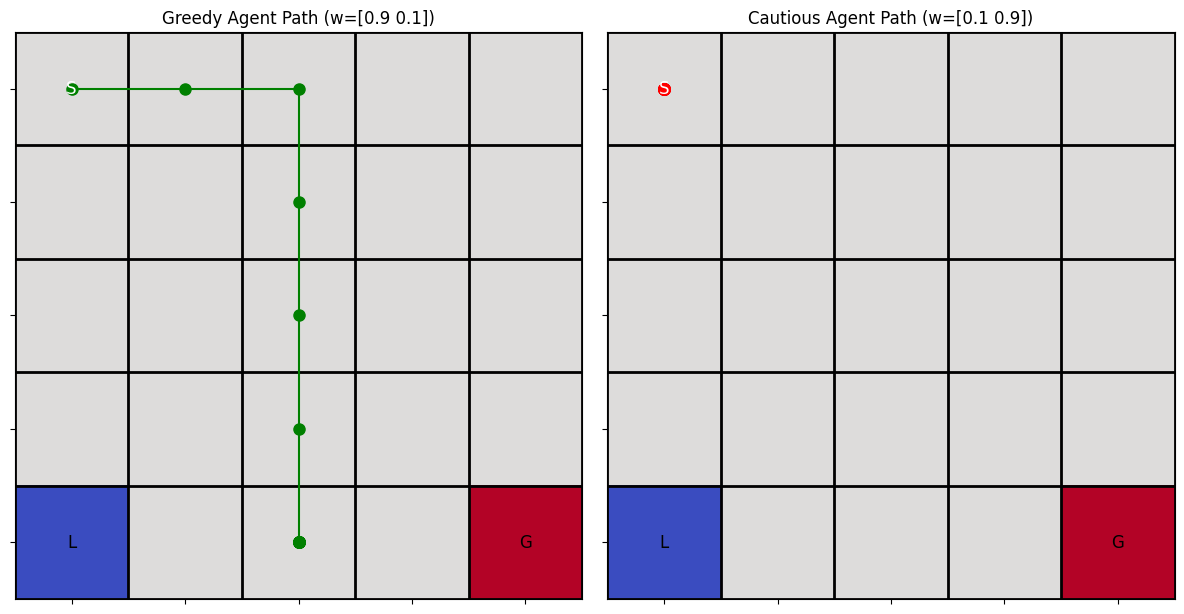

In [ ]:
# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

env.render(ax1, path_greedy, 'green', f'Greedy Agent Path (w={weights_greedy})')
env.render(ax2, path_cautious, 'red', f'Cautious Agent Path (w={weights_cautious})')

plt.tight_layout()
plt.show()

In [ ]:



# Agent 2: "Cautious" - cares much more about avoiding lava
weights_cautious = np.array([0.1, 0.9])
agent_cautious = MORLAgent(env)
train(agent_cautious, weights_cautious)
path_cautious = evaluate(agent_cautious, weights_cautious)

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

env.render(ax1, path_greedy, 'green', f'Greedy Agent Path (w={weights_greedy})')
env.render(ax2, path_cautious, 'red', f'Cautious Agent Path (w={weights_cautious})')

plt.tight_layout()
plt.show()

# Claude

In [2]:


# --- 1. The Multi-Objective Environment (FIXED) ---

class MultiObjectiveGridWorld:
    def __init__(self, size=5):
        self.size = size
        self.start_pos = [0, 0]
        self.goal_pos = [size - 1, size - 1]
        self.lava_pos = [size - 1, 0]
        self.num_objectives = 2
        self.state_dim = 2  # Agent's (row, col) position
        self.action_dim = 4  # 0: up, 1: down, 2: left, 3: right
        self.agent_pos = None
        self.reset()

    def reset(self):
        # Create a NEW list each time (not modify in place)
        self.agent_pos = self.start_pos.copy()
        return np.array(self.agent_pos)

    def step(self, action):
        # Create a NEW position (don't modify in place)
        new_pos = self.agent_pos.copy()

        # Move agent
        if action == 0:  # up
            new_pos[0] = max(0, new_pos[0] - 1)
        elif action == 1:  # down
            new_pos[0] = min(self.size - 1, new_pos[0] + 1)
        elif action == 2:  # left
            new_pos[1] = max(0, new_pos[1] - 1)
        elif action == 3:  # right
            new_pos[1] = min(self.size - 1, new_pos[1] + 1)

        # Update position
        self.agent_pos = new_pos

        # Calculate reward vector [r_goal, r_safety]
        # Both objectives use positive rewards for clarity
        reward_vector = np.array([0.0, 0.0])
        done = False

        if self.agent_pos == self.goal_pos:
            reward_vector[0] = 10.0  # Big reward for reaching goal
            reward_vector[1] = 0.0   # Neutral safety (goal is safe)
            done = True
        elif self.agent_pos == self.lava_pos:
            reward_vector[0] = 0.0    # No goal reward
            reward_vector[1] = -10.0  # Big penalty for hitting lava
            done = True
        else:
            # Small penalties to encourage efficiency
            reward_vector[0] = -0.1  # Small penalty for not reaching goal yet
            reward_vector[1] = 0.1   # Small reward for staying safe

            # Give distance-based shaping rewards
            dist_to_goal = abs(self.agent_pos[0] - self.goal_pos[0]) + abs(self.agent_pos[1] - self.goal_pos[1])
            dist_to_lava = abs(self.agent_pos[0] - self.lava_pos[0]) + abs(self.agent_pos[1] - self.lava_pos[1])

            # Normalize distances
            max_dist = 2 * (self.size - 1)
            reward_vector[0] += 0.1 * (1 - dist_to_goal / max_dist)  # Closer to goal is better
            reward_vector[1] += 0.1 * (dist_to_lava / max_dist)  # Further from lava is better

        return np.array(self.agent_pos), reward_vector, done

    def render(self, ax, path, color, title):
        ax.clear()
        ax.set_title(title)
        grid = np.zeros((self.size, self.size))
        grid[self.goal_pos[0], self.goal_pos[1]] = 1  # Goal
        grid[self.lava_pos[0], self.lava_pos[1]] = -1  # Lava

        ax.imshow(grid, cmap='coolwarm', interpolation='none', vmin=-1, vmax=1)

        # Plot path
        if len(path) > 0:
            path_rows, path_cols = zip(*path)
            ax.plot(path_cols, path_rows, marker='o', color=color, markersize=8, linestyle='-', linewidth=2)

        # Mark positions
        ax.text(0, 0, 'S', ha='center', va='center', color='white', fontsize=12, weight='bold')
        ax.text(self.goal_pos[1], self.goal_pos[0], 'G', ha='center', va='center', color='black', fontsize=12, weight='bold')
        ax.text(self.lava_pos[1], self.lava_pos[0], 'L', ha='center', va='center', color='white', fontsize=12, weight='bold')

        ax.set_xticks(np.arange(-.5, self.size, 1), minor=True)
        ax.set_yticks(np.arange(-.5, self.size, 1), minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", size=0)
        ax.set_xticklabels([])
        ax.set_yticklabels([])



In [3]:
# --- 2. The Multi-Objective Q-Network ---

class MO_QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_objectives):
        super(MO_QNetwork, self).__init__()
        self.num_objectives = num_objectives
        self.action_dim = action_dim

        self.layers = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim * num_objectives)
        )

    def forward(self, state):
        raw_output = self.layers(state)
        # Reshape to (batch_size, num_actions, num_objectives)
        return raw_output.view(-1, self.action_dim, self.num_objectives)




In [7]:
# --- 3. The MORL Agent (FIXED) ---

class MORLAgent:
    def __init__(self, env, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01,
                 epsilon_decay=0.995, lr=1e-3, batch_size=64):
        self.env = env
        self.state_dim = env.state_dim
        self.action_dim = env.action_dim
        self.num_objectives = env.num_objectives

        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.policy_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = deque(maxlen=10000)

    def select_action(self, state, preference_weights):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q_vectors = self.policy_net(state_tensor)

            # Scalarize using preference weights
            scalarized_q_values = torch.matmul(q_vectors, preference_weights.unsqueeze(1)).squeeze()
            return scalarized_q_values.argmax().item()

    def store_transition(self, state, action, reward_vector, next_state, done):
        # Store copies to avoid reference issues
        self.replay_buffer.append((
            state.copy(),
            action,
            reward_vector.copy(),
            next_state.copy(),
            done
        ))

    def optimize_model(self, preference_weights):
        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, reward_vectors, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        reward_vectors = torch.FloatTensor(np.array(reward_vectors)).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.BoolTensor(dones).to(self.device)

        # Get Q-vectors for taken actions
        current_q_vectors = self.policy_net(states)
        action_indices = actions.unsqueeze(1).unsqueeze(2).expand(-1, 1, self.num_objectives)
        current_q_vectors = current_q_vectors.gather(1, action_indices).squeeze(1)

        with torch.no_grad():
            # Double DQN: use policy net to select actions, target net to evaluate
            next_q_vectors_policy = self.policy_net(next_states)
            scalarized_next_q = torch.matmul(next_q_vectors_policy, preference_weights.unsqueeze(1)).squeeze(2)
            best_next_actions = scalarized_next_q.argmax(dim=1)

            # Get Q-vectors from target net
            next_q_vectors_target = self.target_net(next_states)
            action_indices = best_next_actions.unsqueeze(1).unsqueeze(2).expand(-1, 1, self.num_objectives)
            best_next_q_vectors = next_q_vectors_target.gather(1, action_indices).squeeze(1)

            # Set to zero if done
            best_next_q_vectors[dones] = 0.0

            # Bellman target
            target_q_vectors = reward_vectors + self.gamma * best_next_q_vectors

        # MSE loss on vectors
        loss = nn.MSELoss()(current_q_vectors, target_q_vectors)

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        # Decay epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update_target_net(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())




In [8]:
# --- 4. Training and Evaluation (IMPROVED) ---

def train(agent, preference_weights, episodes=500):
    print(f"\n--- Training with weights {preference_weights} ---")
    preference_weights_tensor = torch.FloatTensor(preference_weights).to(agent.device)

    episode_rewards = []
    for episode in range(episodes):
        state = agent.env.reset()
        done = False
        total_reward = np.zeros(2)
        steps = 0
        max_steps = 50

        while not done and steps < max_steps:
            action = agent.select_action(state, preference_weights_tensor)
            next_state, reward_vector, done = agent.env.step(action)
            agent.store_transition(state, action, reward_vector, next_state, done)
            agent.optimize_model(preference_weights_tensor)
            state = next_state
            total_reward += reward_vector
            steps += 1

        episode_rewards.append(total_reward)

        # Update target network
        if episode % 10 == 0:
            agent.update_target_net()

        # Print progress
        if episode % 50 == 0:
            scalarized = np.dot(total_reward, preference_weights)
            print(f"Episode {episode}/{episodes}, Epsilon: {agent.epsilon:.3f}, "
                  f"Rewards: {total_reward}, Scalarized: {scalarized:.2f}")

def evaluate(agent, preference_weights, max_steps=30):
    path = []
    state = agent.env.reset()
    path.append(state.tolist())
    done = False

    # Store original epsilon and set to 0 for greedy evaluation
    original_epsilon = agent.epsilon
    agent.epsilon = 0

    preference_weights_tensor = torch.FloatTensor(preference_weights).to(agent.device)

    steps = 0
    total_reward = np.zeros(2)

    while not done and steps < max_steps:
        action = agent.select_action(state, preference_weights_tensor)
        state, reward_vector, done = agent.env.step(action)
        path.append(state.tolist())
        total_reward += reward_vector
        steps += 1

    # Restore epsilon
    agent.epsilon = original_epsilon

    print(f"Evaluation complete: Total reward = {total_reward}, "
          f"Scalarized = {np.dot(total_reward, preference_weights):.2f}, "
          f"Steps = {steps}")

    return path


In [9]:
env = MultiObjectiveGridWorld(size=5)


In [10]:


# Agent 1: "Greedy" - prioritizes reaching the goal
weights_greedy = np.array([0.9, 0.1])
agent_greedy = MORLAgent(env)
train(agent_greedy, weights_greedy)
path_greedy = evaluate(agent_greedy, weights_greedy)



--- Training with weights [0.9 0.1] ---
Episode 0/300, Epsilon: 1.000, Rewards: [-1.3375 -7.8375], Scalarized: -1.99
Episode 50/300, Epsilon: 0.012, Rewards: [9.65  1.025], Scalarized: 8.79
Episode 100/300, Epsilon: 0.010, Rewards: [-0.8875  8.1625], Scalarized: 0.02
Episode 150/300, Epsilon: 0.010, Rewards: [9.05 3.65], Scalarized: 8.51
Episode 200/300, Epsilon: 0.010, Rewards: [9.55  1.325], Scalarized: 8.73
Episode 250/300, Epsilon: 0.010, Rewards: [9.65  1.025], Scalarized: 8.79
Evaluation complete: Total reward = [9.65  1.175], Scalarized = 8.80, Steps = 8


In [13]:

# Agent 2: "Cautious" - prioritizes avoiding lava
weights_cautious = np.array([0.1, 0.9])
agent_cautious = MORLAgent(env)
train(agent_cautious, weights_cautious)
path_cautious = evaluate(agent_cautious, weights_cautious)


--- Training with weights [0.1 0.9] ---
Episode 0/300, Epsilon: 1.000, Rewards: [-3.675  8.5  ], Scalarized: 7.28
Episode 50/300, Epsilon: 0.010, Rewards: [-4.9875  7.5125], Scalarized: 6.26
Episode 100/300, Epsilon: 0.010, Rewards: [-1.4625  8.6125], Scalarized: 7.60
Episode 150/300, Epsilon: 0.010, Rewards: [-2.75  9.75], Scalarized: 8.50
Episode 200/300, Epsilon: 0.010, Rewards: [-2.4125  9.7375], Scalarized: 8.52
Episode 250/300, Epsilon: 0.010, Rewards: [-2.575  9.925], Scalarized: 8.67
Evaluation complete: Total reward = [-1.575  5.925], Scalarized = 5.18, Steps = 30


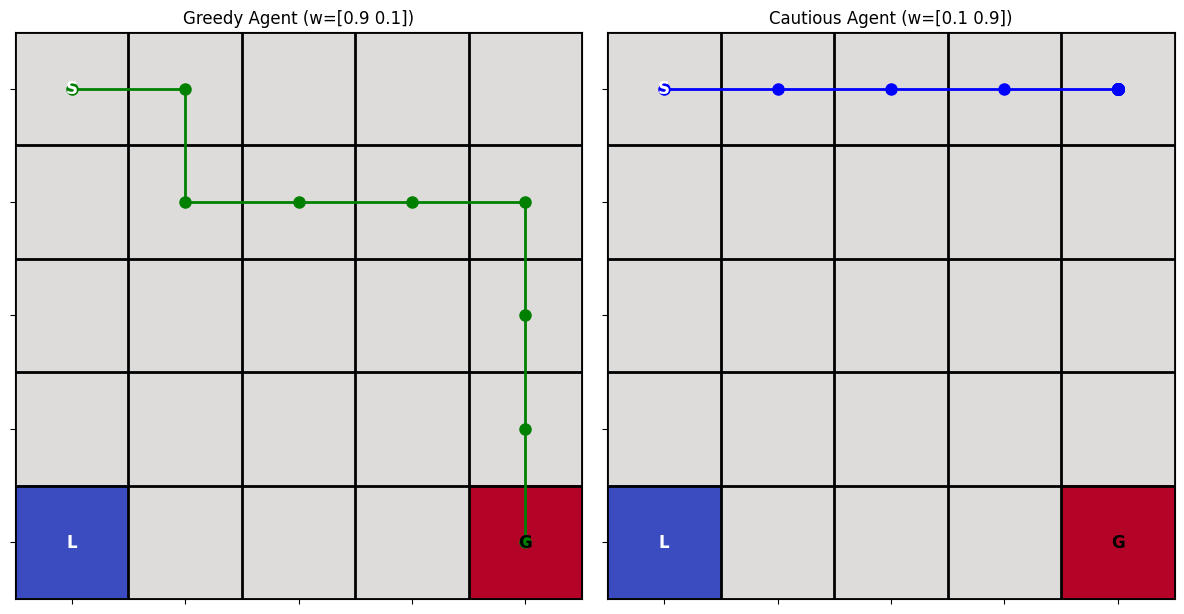

In [14]:


# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

env.render(ax1, path_greedy, 'green', f'Greedy Agent (w={weights_greedy})')
env.render(ax2, path_cautious, 'blue', f'Cautious Agent (w={weights_cautious})')

plt.tight_layout()
plt.show()

# GPT 5

In [21]:
from collections import deque
import matplotlib.pyplot as plt


# ---------------------------
# Reproducibility (optional)
# ---------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


# --- 1. The Multi-Objective Environment ---

class MultiObjectiveGridWorld:
    def __init__(self, size=5):
        self.size = size
        self.agent_pos = [0, 0]
        self.goal_pos = [size - 1, size - 1]
        self.lava_pos = [size - 1, 0]
        self.num_objectives = 2
        self.state_dim = 2  # Agent's (row, col) position
        self.action_dim = 4  # 0: up, 1: down, 2: left, 3: right

    def reset(self):
        self.agent_pos = [0, 0]
        return np.array(self.agent_pos, dtype=np.float32)

    def step(self, action):
        # Move agent
        if action == 0:
            self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
        elif action == 1:
            self.agent_pos[0] = min(self.size - 1, self.agent_pos[0] + 1)
        elif action == 2:
            self.agent_pos[1] = max(0, self.agent_pos[1] - 1)
        elif action == 3:
            self.agent_pos[1] = min(self.size - 1, self.agent_pos[1] + 1)

        # Get reward vector [r_goal, r_lava]
        reward_vector = np.array([0.0, 0.0], dtype=np.float32)
        done = False

        if self.agent_pos == self.goal_pos:
            reward_vector[0] = 1.0
            done = True
        elif self.agent_pos == self.lava_pos:
            reward_vector[1] = -1.0
            done = True

        return np.array(self.agent_pos, dtype=np.float32), reward_vector, done

    def render(self, ax, path, color, title, show_steps=True):
      ax.clear()
      ax.set_title(title)

      # Discrete grid: 0 empty, 1 lava, 2 goal
      grid = np.zeros((self.size, self.size), dtype=int)
      grid[self.lava_pos[0], self.lava_pos[1]] = 1
      grid[self.goal_pos[0], self.goal_pos[1]] = 2

      cmap = ListedColormap(['white', '#e74c3c', '#2ecc71'])  # empty, lava (red), goal (green)
      norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

      # Put (0,0) at bottom-left
      ax.imshow(grid, cmap=cmap, norm=norm, origin='lower', interpolation='none')

      # Plot path
      if len(path) > 1:
          rows = [int(p[0]) for p in path]
          cols = [int(p[1]) for p in path]
          ax.plot(cols, rows, marker='o', color=color, markersize=6, linewidth=2)

          if show_steps:
              for i, (r, c) in enumerate(path):
                  ax.text(int(c), int(r), str(i), ha='center', va='center', fontsize=8, color='black')

          # Optional: arrows to show direction (comment out if too busy)
          # for (r0, c0), (r1, c1) in zip(path[:-1], path[1:]):
          #     ax.arrow(c0, r0, c1-c0, r1-r0, head_width=0.15, head_length=0.15,
          #              fc=color, ec=color, length_includes_head=True, alpha=0.8)

      # Labels for start/goal/lava
      ax.text(0, 0, 'S', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
      ax.text(self.goal_pos[1], self.goal_pos[0], 'G', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
      ax.text(self.lava_pos[1], self.lava_pos[0], 'L', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

      # Grid and axes
      ax.set_xticks(range(self.size))
      ax.set_yticks(range(self.size))
      ax.set_xlabel('col')
      ax.set_ylabel('row')
      ax.set_xlim(-0.5, self.size - 0.5)
      ax.set_ylim(-0.5, self.size - 0.5)
      ax.set_aspect('equal')
      ax.grid(True, which='both', color='black', linewidth=1, alpha=0.15)

In [22]:
# --- 2. The Multi-Objective Q-Network (The "Reward Head") ---

class MO_QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_objectives):
        super(MO_QNetwork, self).__init__()
        self.num_objectives = num_objectives
        self.action_dim = action_dim

        self.layers = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim * num_objectives)
        )

    def forward(self, state):
        raw_output = self.layers(state)
        # Reshape to (batch_size, num_actions, num_objectives)
        return raw_output.view(-1, self.action_dim, self.num_objectives)




In [23]:
# --- 3. The MORL Agent ---

class MORLAgent:
    def __init__(self, env, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995, lr=1e-4, batch_size=64):
        self.env = env
        self.state_dim = env.state_dim
        self.action_dim = env.action_dim
        self.num_objectives = env.num_objectives

        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.policy_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = deque(maxlen=10000)

    def select_action(self, state, preference_weights, greedy=False):
        # greedy=True ignores epsilon
        if (not greedy) and (random.random() < self.epsilon):
            return random.randint(0, self.action_dim - 1)

        with torch.no_grad():
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            q_vectors = self.policy_net(state_tensor)  # (1, num_actions, num_objectives)
            w = preference_weights.to(self.device).view(1, 1, -1)  # (1, 1, num_objectives)
            scalarized_q_values = (q_vectors * w).sum(dim=2)  # (1, num_actions)
            action = scalarized_q_values.argmax(dim=1).item()
            return action

    def store_transition(self, state, action, reward_vector, next_state, done):
        self.replay_buffer.append((state, action, reward_vector, next_state, done))

    def optimize_model(self, preference_weights):
        if len(self.replay_buffer) < self.batch_size:
            return None

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, reward_vectors, next_states, dones = zip(*batch)

        states = torch.as_tensor(np.array(states), dtype=torch.float32, device=self.device)
        actions = torch.as_tensor(actions, dtype=torch.long, device=self.device)
        reward_vectors = torch.as_tensor(np.array(reward_vectors), dtype=torch.float32, device=self.device)
        next_states = torch.as_tensor(np.array(next_states), dtype=torch.float32, device=self.device)
        dones = torch.as_tensor(dones, dtype=torch.bool, device=self.device)

        # Current Q-vectors for taken actions
        q_vectors_all = self.policy_net(states)  # (B, A, O)
        q_vectors_current = q_vectors_all.gather(
            1, actions.view(-1, 1, 1).expand(-1, 1, self.num_objectives)
        ).squeeze(1)  # (B, O)

        with torch.no_grad():
            next_q_vectors = self.target_net(next_states)  # (B, A, O)
            w = preference_weights.to(self.device).view(1, 1, -1)  # (1, 1, O)
            scalarized_next_q = (next_q_vectors * w).sum(dim=2)  # (B, A)
            best_next_actions = scalarized_next_q.argmax(dim=1)  # (B,)
            best_next_q_vectors = next_q_vectors.gather(
                1, best_next_actions.view(-1, 1, 1).expand(-1, 1, self.num_objectives)
            ).squeeze(1)  # (B, O)

            # Zero future return on terminal transitions
            best_next_q_vectors[dones] = 0.0

            target_q_vectors = reward_vectors + self.gamma * best_next_q_vectors  # (B, O)

        loss = nn.MSELoss()(q_vectors_current, target_q_vectors)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Epsilon decay
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        return loss.item()

    def update_target_net(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()




In [24]:
# --- 4. Training and Evaluation ---

def train(agent, preference_weights, episodes=500, max_steps_per_episode=50, target_update_every=10, verbose_every=10):
    print(f"--- Training with weights {preference_weights} ---")
    preference_weights_tensor = torch.as_tensor(preference_weights, dtype=torch.float32, device=agent.device)

    for episode in range(episodes):
        state = agent.env.reset()
        done = False
        steps = 0

        # IMPORTANT: cap episode length to avoid infinite loops
        while not done and steps < max_steps_per_episode:
            action = agent.select_action(state, preference_weights_tensor)
            next_state, reward_vector, done = agent.env.step(action)
            agent.store_transition(state, action, reward_vector, next_state, done)
            agent.optimize_model(preference_weights_tensor)
            state = next_state
            steps += 1

        # Periodic target network update
        if (episode + 1) % target_update_every == 0:
            agent.update_target_net()

        if (episode + 1) % verbose_every == 0:
            print(f"Episode {episode + 1}/{episodes} (steps: {steps})")


def evaluate(agent, preference_weights, max_steps=20):
    path = []
    state = agent.env.reset()
    path.append(list(map(int, state)))  # cast to ints for plotting
    done = False

    # Temporarily force greedy
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0
    preference_weights_tensor = torch.as_tensor(preference_weights, dtype=torch.float32, device=agent.device)

    steps = 0
    while not done and steps < max_steps:
        action = agent.select_action(state, preference_weights_tensor, greedy=True)
        state, _, done = agent.env.step(action)
        path.append(list(map(int, state)))
        steps += 1

    # Restore epsilon
    agent.epsilon = old_epsilon
    return path




--- Training with weights [0.9 0.1] ---
Episode 10/500 (steps: 14)
Episode 20/500 (steps: 8)
Episode 30/500 (steps: 8)
Episode 40/500 (steps: 8)
Episode 50/500 (steps: 8)
Episode 60/500 (steps: 27)
Episode 70/500 (steps: 200)
Episode 80/500 (steps: 200)
Episode 90/500 (steps: 200)
Episode 100/500 (steps: 200)
Episode 110/500 (steps: 200)
Episode 120/500 (steps: 91)
Episode 130/500 (steps: 200)
Episode 140/500 (steps: 200)
Episode 150/500 (steps: 200)
Episode 160/500 (steps: 200)
Episode 170/500 (steps: 200)
Episode 180/500 (steps: 14)
Episode 190/500 (steps: 13)
Episode 200/500 (steps: 25)
Episode 210/500 (steps: 200)
Episode 220/500 (steps: 200)
Episode 230/500 (steps: 200)
Episode 240/500 (steps: 44)
Episode 250/500 (steps: 8)
Episode 260/500 (steps: 8)
Episode 270/500 (steps: 8)
Episode 280/500 (steps: 8)
Episode 290/500 (steps: 8)
Episode 300/500 (steps: 8)
Episode 310/500 (steps: 8)
Episode 320/500 (steps: 8)
Episode 330/500 (steps: 8)
Episode 340/500 (steps: 8)
Episode 350/500 (s

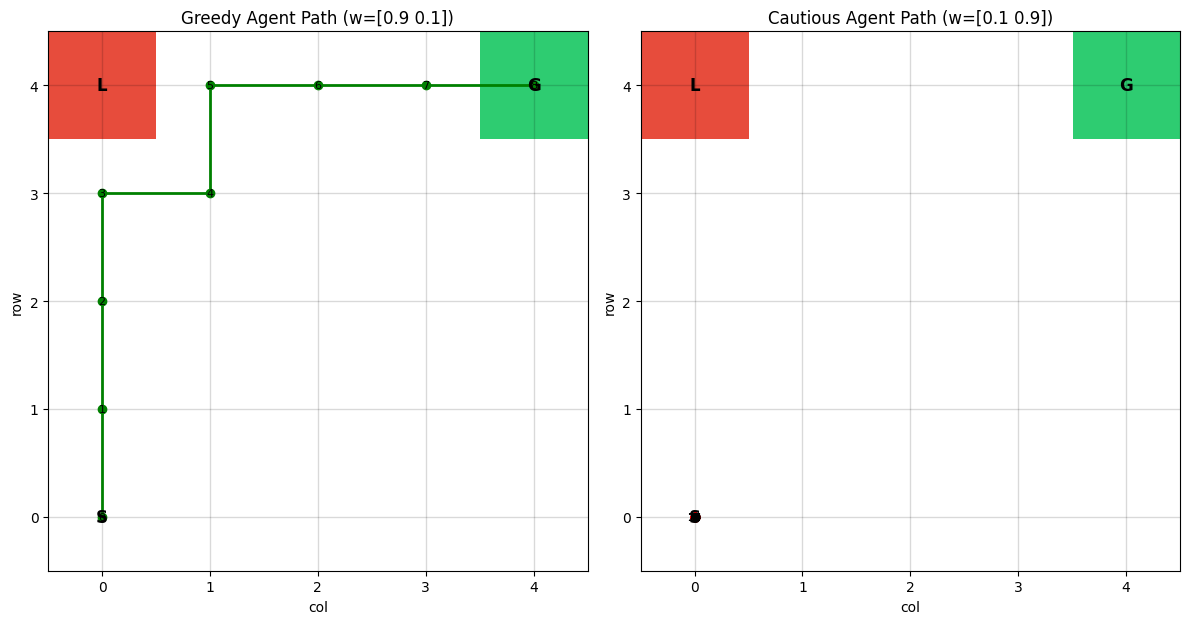

In [26]:
# ---------------------------
# Run
# ---------------------------
env = MultiObjectiveGridWorld(size=5)

# Agent 1: "Greedy" - cares much more about the goal
weights_greedy = np.array([0.9, 0.1], dtype=np.float32)
agent_greedy = MORLAgent(env)
train(agent_greedy, weights_greedy, episodes=500, max_steps_per_episode=200, target_update_every=10)
path_greedy = evaluate(agent_greedy, weights_greedy, max_steps=20)

# Agent 2: "Cautious" - cares much more about avoiding lava
weights_cautious = np.array([0.1, 0.9], dtype=np.float32)
agent_cautious = MORLAgent(env)
train(agent_cautious, weights_cautious, episodes=500, max_steps_per_episode=200, target_update_every=10)
path_cautious = evaluate(agent_cautious, weights_cautious, max_steps=20)

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
env.render(ax1, path_greedy, 'green', f'Greedy Agent Path (w={weights_greedy})')
env.render(ax2, path_cautious, 'red', f'Cautious Agent Path (w={weights_cautious})')
plt.tight_layout()
plt.show()

In [27]:
weights_cautious = np.array([0.4, 0.6], dtype=np.float32)
agent_cautious = MORLAgent(env)
train(agent_cautious, weights_cautious, episodes=500, max_steps_per_episode=500, target_update_every=10)
path_cautious = evaluate(agent_cautious, weights_cautious, max_steps=20)

--- Training with weights [0.4 0.6] ---
Episode 10/500 (steps: 500)
Episode 20/500 (steps: 500)
Episode 30/500 (steps: 500)
Episode 40/500 (steps: 419)
Episode 50/500 (steps: 500)
Episode 60/500 (steps: 500)
Episode 70/500 (steps: 64)
Episode 80/500 (steps: 500)
Episode 90/500 (steps: 500)
Episode 100/500 (steps: 500)
Episode 110/500 (steps: 500)
Episode 120/500 (steps: 500)
Episode 130/500 (steps: 500)
Episode 140/500 (steps: 500)
Episode 150/500 (steps: 500)
Episode 160/500 (steps: 87)
Episode 170/500 (steps: 500)
Episode 180/500 (steps: 500)
Episode 190/500 (steps: 500)
Episode 200/500 (steps: 500)
Episode 210/500 (steps: 500)
Episode 220/500 (steps: 500)
Episode 230/500 (steps: 500)
Episode 240/500 (steps: 500)
Episode 250/500 (steps: 500)
Episode 260/500 (steps: 185)
Episode 270/500 (steps: 500)
Episode 280/500 (steps: 500)
Episode 290/500 (steps: 500)
Episode 300/500 (steps: 500)
Episode 310/500 (steps: 500)
Episode 320/500 (steps: 500)
Episode 330/500 (steps: 500)
Episode 340/50

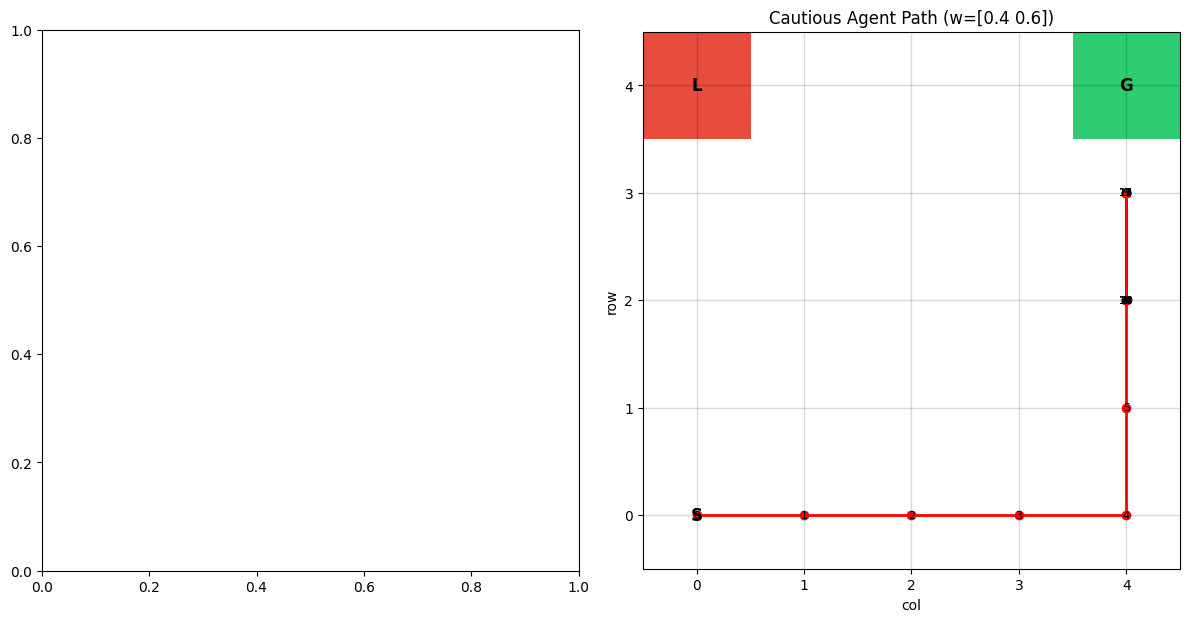

In [29]:
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
env.render(ax2, path_cautious, 'red', f'Cautious Agent Path (w={weights_cautious})')
plt.tight_layout()
plt.show()

In [20]:
from matplotlib.colors import ListedColormap, BoundaryNorm

def render(self, ax, path, color, title, show_steps=True):
    ax.clear()
    ax.set_title(title)

    # Discrete grid: 0 empty, 1 lava, 2 goal
    grid = np.zeros((self.size, self.size), dtype=int)
    grid[self.lava_pos[0], self.lava_pos[1]] = 1
    grid[self.goal_pos[0], self.goal_pos[1]] = 2

    cmap = ListedColormap(['white', '#e74c3c', '#2ecc71'])  # empty, lava (red), goal (green)
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    # Put (0,0) at bottom-left
    ax.imshow(grid, cmap=cmap, norm=norm, origin='lower', interpolation='none')

    # Plot path
    if len(path) > 1:
        rows = [int(p[0]) for p in path]
        cols = [int(p[1]) for p in path]
        ax.plot(cols, rows, marker='o', color=color, markersize=6, linewidth=2)

        if show_steps:
            for i, (r, c) in enumerate(path):
                ax.text(int(c), int(r), str(i), ha='center', va='center', fontsize=8, color='black')

        # Optional: arrows to show direction (comment out if too busy)
        # for (r0, c0), (r1, c1) in zip(path[:-1], path[1:]):
        #     ax.arrow(c0, r0, c1-c0, r1-r0, head_width=0.15, head_length=0.15,
        #              fc=color, ec=color, length_includes_head=True, alpha=0.8)

    # Labels for start/goal/lava
    ax.text(0, 0, 'S', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
    ax.text(self.goal_pos[1], self.goal_pos[0], 'G', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
    ax.text(self.lava_pos[1], self.lava_pos[0], 'L', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

    # Grid and axes
    ax.set_xticks(range(self.size))
    ax.set_yticks(range(self.size))
    ax.set_xlabel('col')
    ax.set_ylabel('row')
    ax.set_xlim(-0.5, self.size - 0.5)
    ax.set_ylim(-0.5, self.size - 0.5)
    ax.set_aspect('equal')
    ax.grid(True, which='both', color='black', linewidth=1, alpha=0.15)

# MORL


In [30]:
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---------------------------
# Reproducibility
# ---------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# ---------------------------
# Pareto utilities
# ---------------------------
def pareto_front(points):
    # points: list of (x,y), maximize both
    unique = list({(int(x), int(y)) for (x, y) in points})
    nd = []
    for i, p in enumerate(unique):
        dominated = False
        for j, q in enumerate(unique):
            if i == j:
                continue
            if (q[0] >= p[0] and q[1] >= p[1]) and (q[0] > p[0] or q[1] > p[1]):
                dominated = True
                break
        if not dominated:
            nd.append(p)
    # sort by x then y for plotting
    nd.sort(key=lambda t: (t[0], t[1]))
    return nd, unique

# ---------------------------
# 1) Multi-Objective Coins Environment
# ---------------------------
class MultiObjectiveCoinsWorld:
    """
    Grid with two types of coins: red and blue.
    Reward vector per step: [red_collected, blue_collected].
    Episode ends when step budget is exhausted or all coins collected.
    State is a 3-channel grid (agent, red, blue), flattened to a vector.
    """
    def __init__(self, size=7, red_coins=None, blue_coins=None, max_steps=20):
        self.size = size
        self.max_steps = max_steps
        self.agent_start = (size // 2, size // 2)

        # Default clusters (top-right red, bottom-left blue)
        if red_coins is None:
            red_coins = [(0, 6), (1, 6), (0, 5)]
        if blue_coins is None:
            blue_coins = [(6, 0), (6, 1), (5, 0)]
        self.red_coins_init = list(red_coins)
        self.blue_coins_init = list(blue_coins)

        self.state_dim = self.size * self.size * 3
        self.action_dim = 4  # up, down, left, right
        self.num_objectives = 2

        self.reset()

    def reset(self):
        self.agent_pos = list(self.agent_start)
        self.red_coins = set(self.red_coins_init)
        self.blue_coins = set(self.blue_coins_init)
        self.steps = 0
        return self._obs()

    def _obs(self):
        # 3 channels: agent, red, blue
        grid = np.zeros((self.size, self.size, 3), dtype=np.float32)
        ar, ac = self.agent_pos
        grid[ar, ac, 0] = 1.0
        for r, c in self.red_coins:
            grid[r, c, 1] = 1.0
        for r, c in self.blue_coins:
            grid[r, c, 2] = 1.0
        return grid.reshape(-1)

    def step(self, action):
        # Move
        if action == 0:   # up
            self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
        elif action == 1: # down
            self.agent_pos[0] = min(self.size - 1, self.agent_pos[0] + 1)
        elif action == 2: # left
            self.agent_pos[1] = max(0, self.agent_pos[1] - 1)
        elif action == 3: # right
            self.agent_pos[1] = min(self.size - 1, self.agent_pos[1] + 1)

        reward_vector = np.array([0.0, 0.0], dtype=np.float32)
        pos = tuple(self.agent_pos)

        # Collect any coin at current position
        if pos in self.red_coins:
            self.red_coins.remove(pos)
            reward_vector[0] += 1.0
        if pos in self.blue_coins:
            self.blue_coins.remove(pos)
            reward_vector[1] += 1.0

        self.steps += 1
        done = False
        if self.steps >= self.max_steps or (len(self.red_coins) == 0 and len(self.blue_coins) == 0):
            done = True

        return self._obs(), reward_vector, done

    def render(self, ax, path, color, title, show_steps=True):
        ax.clear()
        ax.set_title(title)

        # Discrete grid: 0 empty, 1 red coin, 2 blue coin
        grid = np.zeros((self.size, self.size), dtype=int)
        for r, c in self.red_coins_init:
            grid[r, c] = 1
        for r, c in self.blue_coins_init:
            grid[r, c] = 2

        cmap = ListedColormap(['white', '#e74c3c', '#3498db'])  # empty, red, blue
        norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

        ax.imshow(grid, cmap=cmap, norm=norm, origin='lower', interpolation='none')

        if len(path) > 1:
            rows = [int(p[0]) for p in path]
            cols = [int(p[1]) for p in path]
            ax.plot(cols, rows, marker='o', color=color, markersize=5, linewidth=2)
            if show_steps:
                for i, (r, c) in enumerate(path):
                    ax.text(int(c), int(r), str(i), ha='center', va='center', fontsize=7, color='black')

        # Start marker
        ax.text(self.agent_start[1], self.agent_start[0], 'S', ha='center', va='center',
                color='black', fontsize=12, fontweight='bold')

        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.set_xlabel('col')
        ax.set_ylabel('row')
        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(-0.5, self.size - 0.5)
        ax.set_aspect('equal')
        ax.grid(True, which='both', color='black', linewidth=1, alpha=0.15)

# ---------------------------
# 2) Vector-Q Network
# ---------------------------
class MO_QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_objectives):
        super().__init__()
        self.num_objectives = num_objectives
        self.action_dim = action_dim
        self.layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim * num_objectives)
        )

    def forward(self, state):
        out = self.layers(state)
        return out.view(-1, self.action_dim, self.num_objectives)

# ---------------------------
# 3) MORL Agent (vector Q + scalarized greedy via weights)
# ---------------------------
class MORLAgent:
    def __init__(self, env, gamma=0.99, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995, lr=2e-4, batch_size=128):
        self.env = env
        self.state_dim = env.state_dim
        self.action_dim = env.action_dim
        self.num_objectives = env.num_objectives

        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.policy_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = deque(maxlen=50000)

    def select_action(self, state, w, greedy=False):
        if (not greedy) and (random.random() < self.epsilon):
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            q_vec = self.policy_net(s)  # (1, A, O)
            w = torch.as_tensor(w, dtype=torch.float32, device=self.device).view(1, 1, -1)
            scalar_q = (q_vec * w).sum(dim=2)  # (1, A)
            return scalar_q.argmax(dim=1).item()

    def store(self, s, a, r_vec, ns, done):
        self.replay_buffer.append((s, a, r_vec, ns, done))

    def optimize(self, w):
        if len(self.replay_buffer) < self.batch_size:
            return None
        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.as_tensor(np.array(states), dtype=torch.float32, device=self.device)
        actions = torch.as_tensor(actions, dtype=torch.long, device=self.device)
        rewards = torch.as_tensor(np.array(rewards), dtype=torch.float32, device=self.device)
        next_states = torch.as_tensor(np.array(next_states), dtype=torch.float32, device=self.device)
        dones = torch.as_tensor(dones, dtype=torch.bool, device=self.device)

        q_all = self.policy_net(states)  # (B, A, O)
        q_taken = q_all.gather(1, actions.view(-1,1,1).expand(-1,1,self.num_objectives)).squeeze(1)  # (B, O)

        with torch.no_grad():
            next_q_all = self.target_net(next_states)  # (B, A, O)
            w_t = torch.as_tensor(w, dtype=torch.float32, device=self.device).view(1,1,-1)
            scalar_next = (next_q_all * w_t).sum(dim=2)  # (B, A)
            best_next_actions = scalar_next.argmax(dim=1)  # (B,)
            best_next_q_vec = next_q_all.gather(1, best_next_actions.view(-1,1,1).expand(-1,1,self.num_objectives)).squeeze(1)  # (B, O)
            best_next_q_vec[dones] = 0.0
            target_vec = rewards + self.gamma * best_next_q_vec

        loss = nn.MSELoss()(q_taken, target_vec)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        return loss.item()

    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

# ---------------------------
# 4) Training and Evaluation
# ---------------------------
def train_with_weight_sampling(agent, episodes=1200, target_update_every=20, verbose_every=50):
    print("Training with random preference weights (uniform on simplex)...")
    for ep in range(episodes):
        # Sample a random weight on the 2D simplex
        raw = np.random.dirichlet([1.0, 1.0]).astype(np.float32)  # sums to 1
        w = raw  # [w_red, w_blue]
        s = agent.env.reset()
        done = False
        while not done:
            a = agent.select_action(s, w)
            ns, r_vec, done = agent.env.step(a)
            agent.store(s, a, r_vec, ns, done)
            agent.optimize(w)
            s = ns

        if (ep + 1) % target_update_every == 0:
            agent.update_target()
        if (ep + 1) % verbose_every == 0:
            print(f"Episode {ep+1}/{episodes}, epsilon={agent.epsilon:.3f}")

def evaluate_once(agent, w, greedy=True):
    s = agent.env.reset()
    done = False
    path = [np.argwhere(s.reshape(agent.env.size, agent.env.size, 3)[:,:,0] == 1)[0].tolist()]  # agent pos in grid
    total = np.array([0.0, 0.0], dtype=np.float32)
    old_eps = agent.epsilon
    if greedy:
        agent.epsilon = 0.0
    steps = 0
    while not done and steps < agent.env.max_steps + 5:
        a = agent.select_action(s, w, greedy=True)
        s, r_vec, done = agent.env.step(a)
        total += r_vec
        pos = np.argwhere(s.reshape(agent.env.size, agent.env.size, 3)[:,:,0] == 1)[0].tolist()
        path.append(pos)
        steps += 1
    agent.epsilon = old_eps
    return total, path

def sweep_weights_and_plot_front(agent, num_weights=41):
    weights = [np.array([alpha, 1.0 - alpha], dtype=np.float32) for alpha in np.linspace(0.0, 1.0, num_weights)]
    points = []
    for w in weights:
        tot, _ = evaluate_once(agent, w, greedy=True)
        points.append((int(tot[0]), int(tot[1])))

    front, all_pts = pareto_front(points)

    # Plot in objective space
    plt.figure(figsize=(6,5))
    xs, ys = zip(*all_pts) if all_pts else ([], [])
    plt.scatter(xs, ys, c='#95a5a6', label='Achieved points')
    if front:
        fx, fy = zip(*front)
        plt.scatter(fx, fy, c='#e67e22', label='Pareto front', s=60, zorder=3)
        plt.plot(fx, fy, c='#e67e22', alpha=0.5)
    plt.xlabel('Red collected')
    plt.ylabel('Blue collected')
    plt.title('Objective space with Pareto front')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return front



Training with random preference weights (uniform on simplex)...
Episode 100/1200, epsilon=0.050
Episode 200/1200, epsilon=0.050
Episode 300/1200, epsilon=0.050
Episode 400/1200, epsilon=0.050
Episode 500/1200, epsilon=0.050
Episode 600/1200, epsilon=0.050
Episode 700/1200, epsilon=0.050
Episode 800/1200, epsilon=0.050
Episode 900/1200, epsilon=0.050
Episode 1000/1200, epsilon=0.050
Episode 1100/1200, epsilon=0.050
Episode 1200/1200, epsilon=0.050


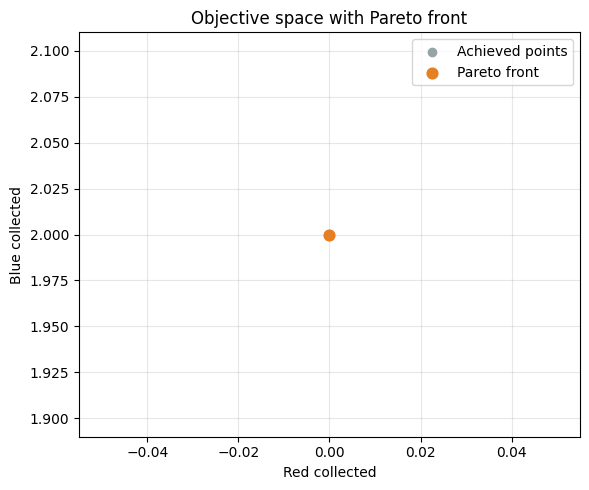

Pareto front (nondominated points): [(0, 2)]


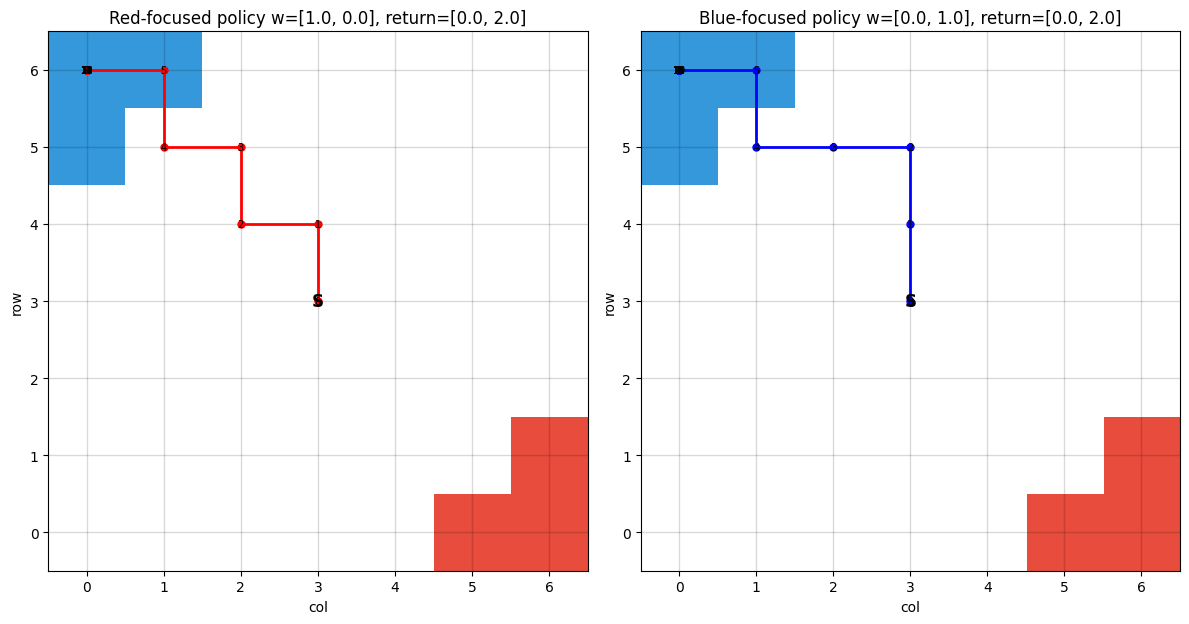

In [31]:
# ---------------------------
# 5) Run the experiment
# ---------------------------
env = MultiObjectiveCoinsWorld(size=7, max_steps=20)
agent = MORLAgent(env)

train_with_weight_sampling(agent, episodes=1200, target_update_every=20, verbose_every=100)

# Visualize Pareto front in objective space
front = sweep_weights_and_plot_front(agent, num_weights=41)
print("Pareto front (nondominated points):", front)

# Show example paths for extreme preferences
w_red = np.array([1.0, 0.0], dtype=np.float32)
w_blue = np.array([0.0, 1.0], dtype=np.float32)
tot_r, path_r = evaluate_once(agent, w_red)
tot_b, path_b = evaluate_once(agent, w_blue)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
env.render(ax1, path_r, color='red', title=f'Red-focused policy w={w_red.tolist()}, return={tot_r.tolist()}')
env.render(ax2, path_b, color='blue', title=f'Blue-focused policy w={w_blue.tolist()}, return={tot_b.tolist()}')
plt.tight_layout()
plt.show()

# F2

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# --- Environment with Clear Trade-offs ---
class MultiObjectiveGridWorld:
    def __init__(self, size=5):
        self.size = size
        self.start_pos = [2, 0]  # Middle left
        self.treasure1_pos = [0, 4]  # Top right - high reward, low risk
        self.treasure2_pos = [4, 4]  # Bottom right - very high reward, high risk
        self.hazards = [[3, 3], [3, 4], [4, 3]]  # Hazards near treasure2

        self.num_objectives = 2  # [reward, safety]
        self.state_dim = 2
        self.action_dim = 4
        self.reset()

    def reset(self):
        self.agent_pos = self.start_pos.copy()
        self.steps_taken = 0
        return np.array(self.agent_pos)

    def step(self, action):
        self.steps_taken += 1
        new_pos = self.agent_pos.copy()

        if action == 0: new_pos[0] = max(0, new_pos[0] - 1)  # up
        elif action == 1: new_pos[0] = min(self.size - 1, new_pos[0] + 1)  # down
        elif action == 2: new_pos[1] = max(0, new_pos[1] - 1)  # left
        elif action == 3: new_pos[1] = min(self.size - 1, new_pos[1] + 1)  # right

        self.agent_pos = new_pos

        # Reward vector: [treasure_reward, safety_score]
        reward_vector = np.array([0.0, 0.0])
        done = False

        # Check outcomes
        if self.agent_pos == self.treasure1_pos:
            reward_vector[0] = 5.0   # Moderate treasure
            reward_vector[1] = 1.0   # Safe
            done = True
        elif self.agent_pos == self.treasure2_pos:
            reward_vector[0] = 10.0  # Big treasure
            reward_vector[1] = 0.5   # Risky but successful
            done = True
        elif self.agent_pos in self.hazards:
            reward_vector[0] = 0.0   # No treasure
            reward_vector[1] = -5.0  # Safety penalty
            done = True
        else:
            # Small penalties for taking time
            reward_vector[0] = -0.01
            reward_vector[1] = 0.01  # Staying safe has tiny reward

            if self.steps_taken >= 30:
                done = True

        return np.array(self.agent_pos), reward_vector, done


# --- Q-Network ---
class MO_QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_objectives):
        super(MO_QNetwork, self).__init__()
        self.num_objectives = num_objectives
        self.action_dim = action_dim

        self.layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim * num_objectives)
        )

    def forward(self, state):
        output = self.layers(state)
        return output.view(-1, self.action_dim, self.num_objectives)


# --- Pareto-Aware MORL Agent ---
class ParetoMORLAgent:
    def __init__(self, env, gamma=0.99, lr=1e-3, batch_size=64):
        self.env = env
        self.gamma = gamma
        self.batch_size = batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Single network that learns all objectives
        self.q_network = MO_QNetwork(env.state_dim, env.action_dim, env.num_objectives).to(self.device)
        self.target_network = MO_QNetwork(env.state_dim, env.action_dim, env.num_objectives).to(self.device)
        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.replay_buffer = deque(maxlen=10000)

        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01

    def select_action(self, state, weights=None):
        """Select action based on weights. If weights=None, use random weights for exploration"""
        if random.random() < self.epsilon:
            return random.randint(0, self.env.action_dim - 1)

        if weights is None:
            # Random weights for diverse exploration
            weights = np.random.dirichlet(np.ones(self.env.num_objectives))

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            weights_tensor = torch.FloatTensor(weights).to(self.device)

            q_vectors = self.q_network(state_tensor)
            scalarized = torch.matmul(q_vectors, weights_tensor.unsqueeze(1)).squeeze()
            return scalarized.argmax().item()

    def train_step(self, weights):
        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(np.array(rewards)).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.BoolTensor(dones).to(self.device)

        weights_tensor = torch.FloatTensor(weights).to(self.device)

        # Current Q-vectors for taken actions
        current_q = self.q_network(states)
        action_indices = actions.unsqueeze(1).unsqueeze(2).expand(-1, 1, self.env.num_objectives)
        current_q = current_q.gather(1, action_indices).squeeze(1)

        # Target Q-vectors
        with torch.no_grad():
            next_q = self.target_network(next_states)
            # Use weights to select best next action
            scalarized_next = torch.matmul(next_q, weights_tensor.unsqueeze(1)).squeeze(2)
            best_actions = scalarized_next.argmax(dim=1)

            action_indices = best_actions.unsqueeze(1).unsqueeze(2).expand(-1, 1, self.env.num_objectives)
            next_q_selected = next_q.gather(1, action_indices).squeeze(1)
            next_q_selected[dones] = 0

            target_q = rewards + self.gamma * next_q_selected

        loss = nn.MSELoss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

    def update_target(self):
        self.target_network.load_state_dict(self.q_network.state_dict())


# --- Pareto Frontier Discovery ---
def discover_pareto_frontier(env, num_weight_samples=20, episodes_per_weight=200):
    """Train with different weight combinations to discover Pareto frontier"""

    print("Discovering Pareto Frontier...")
    agent = ParetoMORLAgent(env)

    # Generate diverse weight combinations
    weight_combinations = []
    for i in range(num_weight_samples):
        w1 = i / (num_weight_samples - 1)
        w2 = 1 - w1
        weight_combinations.append(np.array([w1, w2]))

    # Store results for each weight combination
    results = []

    for idx, weights in enumerate(weight_combinations):
        print(f"\nTraining with weights: [treasure: {weights[0]:.2f}, safety: {weights[1]:.2f}]")

        # Train agent with these weights
        for episode in range(episodes_per_weight):
            state = env.reset()
            done = False

            while not done:
                # Use random weights sometimes for exploration, fixed weights other times
                train_weights = weights if random.random() > 0.3 else None
                action = agent.select_action(state, train_weights)
                next_state, reward_vector, done = env.step(action)

                agent.replay_buffer.append((state, action, reward_vector, next_state, done))
                agent.train_step(weights)

                state = next_state

            if episode % 20 == 0:
                agent.update_target()

            agent.epsilon = max(agent.epsilon_min, agent.epsilon * agent.epsilon_decay)

        # Evaluate the trained policy
        agent.epsilon = 0  # Greedy evaluation
        eval_rewards = []

        for _ in range(10):  # Multiple evaluation runs
            state = env.reset()
            done = False
            total_reward = np.zeros(2)

            while not done:
                action = agent.select_action(state, weights)
                state, reward_vector, done = env.step(action)
                total_reward += reward_vector

            eval_rewards.append(total_reward)

        avg_reward = np.mean(eval_rewards, axis=0)
        results.append({
            'weights': weights.copy(),
            'avg_reward': avg_reward,
            'eval_rewards': eval_rewards
        })

        print(f"Average reward vector: {avg_reward}")

        # Reset epsilon for next weight training
        agent.epsilon = 0.3

    return results


def identify_pareto_optimal(results):
    """Identify which solutions are Pareto optimal (non-dominated)"""
    pareto_optimal = []
    dominated = []

    for i, result_i in enumerate(results):
        is_dominated = False
        reward_i = result_i['avg_reward']

        for j, result_j in enumerate(results):
            if i == j:
                continue

            reward_j = result_j['avg_reward']

            # Check if j dominates i (better or equal in all objectives, better in at least one)
            if all(reward_j >= reward_i) and any(reward_j > reward_i):
                is_dominated = True
                break

        if is_dominated:
            dominated.append(result_i)
        else:
            pareto_optimal.append(result_i)

    return pareto_optimal, dominated


def visualize_pareto_frontier(results):
    """Visualize the Pareto frontier and dominance relationships"""

    pareto_optimal, dominated = identify_pareto_optimal(results)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot 1: Objective Space - Pareto Frontier
    ax1 = axes[0]

    # Plot dominated solutions
    if dominated:
        dom_rewards = np.array([r['avg_reward'] for r in dominated])
        ax1.scatter(dom_rewards[:, 0], dom_rewards[:, 1],
                   c='lightgray', s=100, alpha=0.6, label='Dominated', edgecolors='black')

    # Plot Pareto optimal solutions
    pareto_rewards = np.array([r['avg_reward'] for r in pareto_optimal])
    ax1.scatter(pareto_rewards[:, 0], pareto_rewards[:, 1],
               c='red', s=150, marker='*', label='Pareto Optimal', edgecolors='darkred', linewidth=2)

    # Connect Pareto optimal points
    sorted_indices = np.argsort(pareto_rewards[:, 0])
    sorted_pareto = pareto_rewards[sorted_indices]
    ax1.plot(sorted_pareto[:, 0], sorted_pareto[:, 1], 'r--', alpha=0.5, linewidth=2)

    # Add annotations for some Pareto optimal points
    for i, (reward, result) in enumerate(zip(pareto_rewards, pareto_optimal)):
        if i % 2 == 0:  # Annotate every other point
            ax1.annotate(f'w=[{result["weights"][0]:.1f},{result["weights"][1]:.1f}]',
                        xy=reward, xytext=(5, 5), textcoords='offset points', fontsize=8)

    ax1.set_xlabel('Treasure Reward', fontsize=12)
    ax1.set_ylabel('Safety Score', fontsize=12)
    ax1.set_title('Pareto Frontier in Objective Space', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Weight Space vs Objectives
    ax2 = axes[1]

    all_rewards = np.array([r['avg_reward'] for r in results])
    all_weights = np.array([r['weights'][0] for r in results])  # Weight for treasure objective

    ax2.plot(all_weights, all_rewards[:, 0], 'o-', label='Treasure Reward', color='gold', markersize=8)
    ax2.plot(all_weights, all_rewards[:, 1], 's-', label='Safety Score', color='blue', markersize=8)

    ax2.set_xlabel('Weight on Treasure Objective', fontsize=12)
    ax2.set_ylabel('Objective Value', fontsize=12)
    ax2.set_title('Trade-off: How Weights Affect Each Objective', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Dominance Visualization
    ax3 = axes[2]

    # Show dominance regions
    if len(pareto_optimal) >= 2:
        # Pick two representative Pareto optimal solutions
        idx1, idx2 = 0, len(pareto_optimal) - 1
        point1 = pareto_optimal[idx1]['avg_reward']
        point2 = pareto_optimal[idx2]['avg_reward']

        # Plot the points
        ax3.scatter(*point1, s=200, c='red', marker='*', label=f'Policy A: w={pareto_optimal[idx1]["weights"]}',
                   edgecolors='darkred', linewidth=2)
        ax3.scatter(*point2, s=200, c='blue', marker='*', label=f'Policy B: w={pareto_optimal[idx2]["weights"]}',
                   edgecolors='darkblue', linewidth=2)

        # Show dominated regions
        ax3.axvline(x=point1[0], color='red', linestyle='--', alpha=0.3)
        ax3.axhline(y=point1[1], color='red', linestyle='--', alpha=0.3)
        ax3.axvline(x=point2[0], color='blue', linestyle='--', alpha=0.3)
        ax3.axhline(y=point2[1], color='blue', linestyle='--', alpha=0.3)

        # Add shaded region for dominated area
        ax3.fill_between([0, min(point1[0], point2[0])], 0, min(point1[1], point2[1]),
                        alpha=0.2, color='gray', label='Dominated by both')

        # Add text
        ax3.text(0.5, 0.95, 'Neither A nor B dominates the other!\nThey represent different trade-offs.',
                ha='center', va='top', transform=ax3.transAxes,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
                fontsize=10, fontweight='bold')

    ax3.set_xlabel('Treasure Reward', fontsize=12)
    ax3.set_ylabel('Safety Score', fontsize=12)
    ax3.set_title('Incomparable Solutions (Pareto Optimality)', fontsize=14, fontweight='bold')
    ax3.legend(loc='best')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(-1, max(all_rewards[:, 0]) + 1)
    ax3.set_ylim(min(all_rewards[:, 1]) - 1, max(all_rewards[:, 1]) + 1)

    plt.suptitle('Multi-Objective RL: Pareto Frontier Discovery', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Print analysis
    print("\n" + "="*60)
    print("PARETO OPTIMALITY ANALYSIS")
    print("="*60)
    print(f"\nFound {len(pareto_optimal)} Pareto optimal policies out of {len(results)} trained policies")

    print("\nPareto Optimal Solutions:")
    for i, result in enumerate(pareto_optimal):
        print(f"  Policy {i+1}: weights={result['weights']}, reward={result['avg_reward']}")

    print("\nKey Insight: Pareto optimal solutions cannot be compared without preference!")
    print("- Each represents a different valid trade-off between objectives")
    print("- Improving one objective requires sacrificing the other")
    print("- The choice depends on the decision maker's preferences")



Discovering Pareto Frontier...

Training with weights: [treasure: 0.00, safety: 1.00]
Average reward vector: [-0.3  0.3]

Training with weights: [treasure: 0.07, safety: 0.93]
Average reward vector: [-0.3  0.3]

Training with weights: [treasure: 0.14, safety: 0.86]
Average reward vector: [-0.3  0.3]

Training with weights: [treasure: 0.21, safety: 0.79]
Average reward vector: [-0.3  0.3]

Training with weights: [treasure: 0.29, safety: 0.71]
Average reward vector: [-0.3  0.3]

Training with weights: [treasure: 0.36, safety: 0.64]
Average reward vector: [-0.3  0.3]

Training with weights: [treasure: 0.43, safety: 0.57]
Average reward vector: [-0.3  0.3]

Training with weights: [treasure: 0.50, safety: 0.50]
Average reward vector: [4.95 1.05]

Training with weights: [treasure: 0.57, safety: 0.43]
Average reward vector: [4.95 1.05]

Training with weights: [treasure: 0.64, safety: 0.36]
Average reward vector: [4.95 1.05]

Training with weights: [treasure: 0.71, safety: 0.29]
Average reward

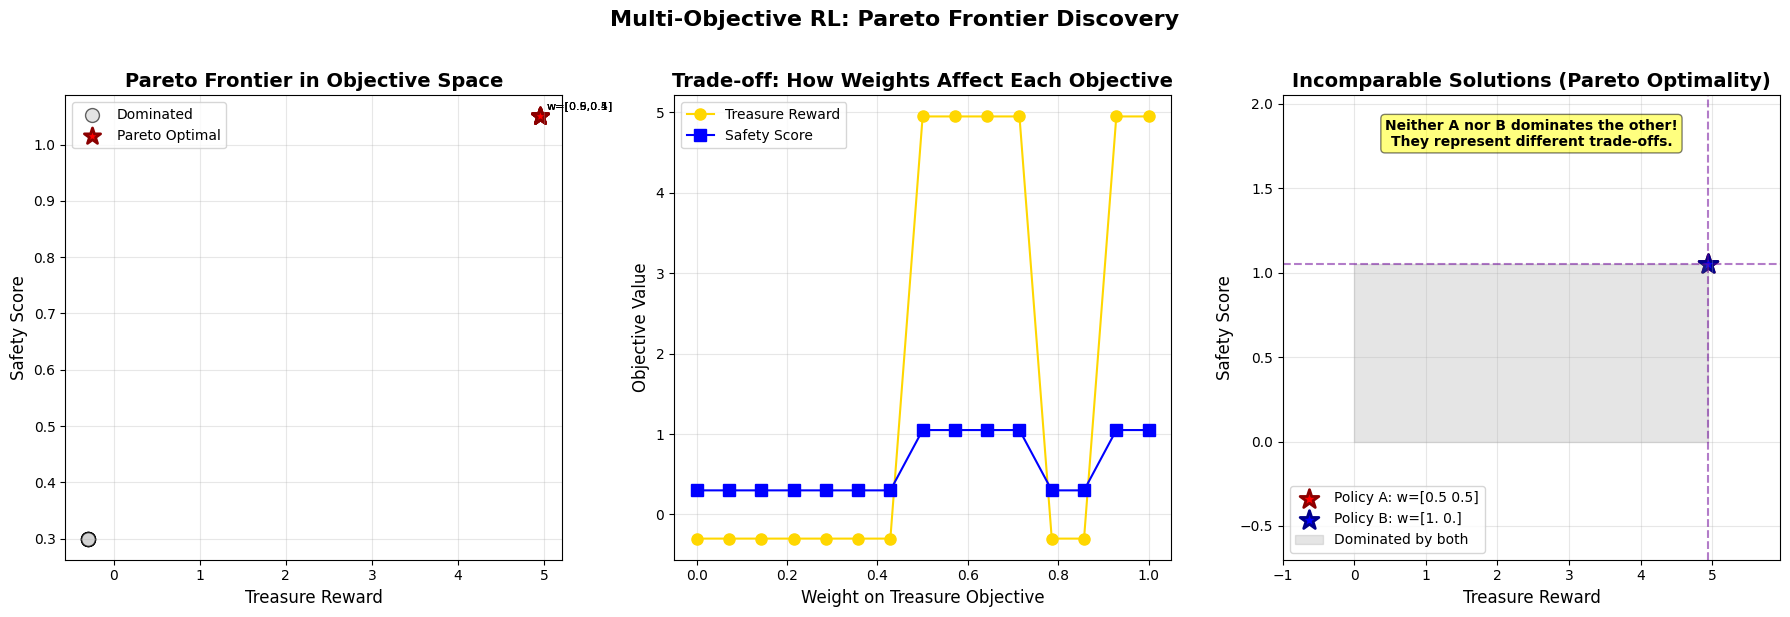


PARETO OPTIMALITY ANALYSIS

Found 6 Pareto optimal policies out of 15 trained policies

Pareto Optimal Solutions:
  Policy 1: weights=[0.5 0.5], reward=[4.95 1.05]
  Policy 2: weights=[0.57142857 0.42857143], reward=[4.95 1.05]
  Policy 3: weights=[0.64285714 0.35714286], reward=[4.95 1.05]
  Policy 4: weights=[0.71428571 0.28571429], reward=[4.95 1.05]
  Policy 5: weights=[0.92857143 0.07142857], reward=[4.95 1.05]
  Policy 6: weights=[1. 0.], reward=[4.95 1.05]

Key Insight: Pareto optimal solutions cannot be compared without preference!
- Each represents a different valid trade-off between objectives
- Improving one objective requires sacrificing the other
- The choice depends on the decision maker's preferences

VECTOR DOMINANCE EXAMPLES

[10  2] vs [8 2]:
  [10  2] dominates [8 2]: True ✓ (better treasure, same safety)

[10  2] vs [ 2 10]:
  [10  2] dominates [ 2 10]: False
  [ 2 10] dominates [10  2]: False
  → Incomparable! Different trade-offs (high treasure vs high safety)


In [33]:


# Create environment
env = MultiObjectiveGridWorld(size=5)

# Discover Pareto frontier by training with different weight combinations
results = discover_pareto_frontier(env, num_weight_samples=15, episodes_per_weight=150)

# Visualize the Pareto frontier and dominance relationships
visualize_pareto_frontier(results)

# Additional analysis: Show that vector comparison is partial ordering
print("\n" + "="*60)
print("VECTOR DOMINANCE EXAMPLES")
print("="*60)

# Example comparisons
v1 = np.array([10, 2])
v2 = np.array([8, 2])
v3 = np.array([2, 10])

def dominates(a, b):
    return all(a >= b) and any(a > b)

print(f"\n{v1} vs {v2}:")
print(f"  {v1} dominates {v2}: {dominates(v1, v2)} ✓ (better treasure, same safety)")

print(f"\n{v1} vs {v3}:")
print(f"  {v1} dominates {v3}: {dominates(v1, v3)}")
print(f"  {v3} dominates {v1}: {dominates(v3, v1)}")
print(f"  → Incomparable! Different trade-offs (high treasure vs high safety)")